## Imports of standard libraries

In [1]:
# Standard Libraries
import os
import sys
import math
import ast
import pickle
import warnings
from pathlib import Path

# Scientific Libraries
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from numpy.polynomial.polynomial import Polynomial

# Machine Learning Libraries
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import seaborn as sns

# IPython Display and Widget Libraries
from IPython.display import display, HTML
import ipywidgets
from ipywidgets import IntSlider, Dropdown, RadioButtons, HBox, Checkbox, ToggleButtons, Layout, Box, Button, Label, FloatSlider

# TensorFlow version check
print("TensorFlow version: ", tf.__version__)

# Display Settings
display(HTML("<style>.jp-Cell { width: 80% !important; margin: 0 auto; }</style>"))

# Suppress Warnings
# Suppress specific warning about KMeans memory leak on Windows with MKL
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
# Suppress specific RuntimeWarning about divide by zero
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Project Directory and Data Path Settings
home_dir = Path.cwd().parent
sys.path.append(f"{home_dir}/data_preprocessing/utilities")
data_path = f"{home_dir}/data"

TensorFlow version:  2.10.0


## Data imports

In [2]:
# Specify interval at which data were resampled
interval = '30s'
# Number of padded datapoints at either end of each event in dataset - added at data preprocessing
predefined_max_lag_size = 90
# Choosing which scale to use normalized/original scale
normalized = False

In [3]:
# Define suffix based on whether normalized or not
norm = '_norm' if normalized else ''

# Load the dictionary containing all datasets
with open(f'{data_path}/prepared_datasets/multipar_datasets_{interval}{norm}.pkl', 'rb') as f:
    multipar_datasets = pickle.load(f)

# Convert to NumPy arrays if the data is not already normalized
if normalized:
    multipar_train_dataset_list = multipar_datasets['train_datasets']  # Already NumPy ndarray
    multipar_val_dataset_list = multipar_datasets['val_datasets']
    multipar_test_dataset_list = multipar_datasets['test_datasets']
else:
    multipar_train_dataset_list = multipar_datasets['train_datasets']
    multipar_val_dataset_list = multipar_datasets['val_datasets']
    multipar_test_dataset_list = multipar_datasets['test_datasets']
    for i in range(len(multipar_train_dataset_list)):
        multipar_train_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_train_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    for i in range(len(multipar_val_dataset_list)):
        multipar_val_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_val_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    for i in range(len(multipar_test_dataset_list)):
        multipar_test_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_test_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    multipar_train_dataset_list = [df.to_numpy() for df in multipar_train_dataset_list]  # Convert DataFrame to NumPy
    multipar_val_dataset_list = [df.to_numpy() for df in multipar_val_dataset_list]
    multipar_test_dataset_list = [df.to_numpy() for df in multipar_test_dataset_list]

In [4]:
[len(a) for a in multipar_test_dataset_list]

[2345, 911, 301, 2407, 661, 657, 943, 662]

In [5]:
# Replacing paded values with the lowest value possible in normalized dataset
multipar_train_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_train_dataset_list]
multipar_val_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_val_dataset_list]
multipar_test_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_test_dataset_list]

## Initializing scaler

In [6]:
# Load the dictionary containing all merged datasets
with open(f'{data_path}/prepared_datasets/multipar_datasets_{interval}.pkl', 'rb') as f:
    multipar_datasets = pickle.load(f)

# Accessing train dataset
train_datasets_merged_multi = pd.concat([period.replace(-111, np.nan).dropna() for period in multipar_datasets['train_datasets']])

# Initiating scaler
scaler = MinMaxScaler(feature_range=(0,1))
# Fitting scaller to ALL train data, so we have to concat precipitation events in train dataset
scaler = scaler.fit(train_datasets_merged_multi)

### Import of lists of model names

In [7]:
def list_models(directory):
    '''
    Lists all the models in the directory

    Args:
      directory (str) - path to the folder with forward and backward models
    Returns:
      folder_names (list of str) - list of folder names (model configurations)
    '''
    # Initialize an empty list to store folder names
    folder_names = []
    
    # Iterate over all entries in the directory
    for entry in os.listdir(directory):
        # Join the directory path with the entry name
        full_path = os.path.join(directory, entry)
        
        # Check if the entry is a directory
        if os.path.isdir(full_path):
            # Append the folder name to the list
            folder_names.append(entry)
    
    return folder_names

In [8]:
# Specify the directories with models
folder_with_turb_models = f'{home_dir}/models_archive/turb_models'
folder_with_cond_models = f'{home_dir}/models_archive/cond_models'
folder_with_pH_models = f'{home_dir}/models_archive/pH_models'

In [9]:
# Lists of configurations of models
turb_case_list = [folder_name for folder_name in list_models(folder_with_turb_models)if interval in folder_name]
cond_case_list = [folder_name for folder_name in list_models(folder_with_cond_models)if interval in folder_name]
pH_case_list = [folder_name for folder_name in list_models(folder_with_pH_models)if interval in folder_name]

In [10]:
# List of models
print('Turbidity models:\n\n', pd.Series(turb_case_list))
print()
print('Conductivity models:\n\n', pd.Series(cond_case_list))
print()
print('pH models:\n\n', pd.Series(pH_case_list))

Turbidity models:

 0      interpolation_tuned_CNN-10-20-30s
1      interpolation_tuned_CNN-10-40-30s
2      interpolation_tuned_CNN-10-60-30s
3      interpolation_tuned_CNN-20-20-30s
4      interpolation_tuned_CNN-20-40-30s
5      interpolation_tuned_CNN-20-60-30s
6       interpolation_tuned_CNN-5-20-30s
7       interpolation_tuned_CNN-5-40-30s
8       interpolation_tuned_CNN-5-60-30s
9     interpolation_tuned_LSTM-10-20-30s
10    interpolation_tuned_LSTM-10-40-30s
11    interpolation_tuned_LSTM-10-60-30s
12    interpolation_tuned_LSTM-20-20-30s
13    interpolation_tuned_LSTM-20-40-30s
14    interpolation_tuned_LSTM-20-60-30s
15     interpolation_tuned_LSTM-5-20-30s
16     interpolation_tuned_LSTM-5-40-30s
17     interpolation_tuned_LSTM-5-60-30s
18     interpolation_tuned_MLP-10-20-30s
19     interpolation_tuned_MLP-10-40-30s
20     interpolation_tuned_MLP-10-60-30s
21     interpolation_tuned_MLP-20-20-30s
22     interpolation_tuned_MLP-20-40-30s
23     interpolation_tuned_MLP-20-60-

### Forecasts

In [11]:
def importing_forecasts(folder_with_models, parameter, dataset_type, norma):
    # Create a dictionary to map each parameter to its corresponding index
    par_map = {'turb': (3, turb_case_list),'cond': (0, cond_case_list),'pH': (4, pH_case_list)}

    # Retrieve the corresponding lists using the parameter
    par_col, case_list = par_map.get(parameter, (None, None))
    
    # Indeces of the models
    case_indeces = list(range(len(case_list)))

    # Importing the list of forecasts
    forecast = []
    for case_ind in case_indeces:
        try:
            # Load the pickle file
            with open(f'{folder_with_models}/{case_list[case_ind]}/forecasts/forecasts_{dataset_type}_norm.pkl', 'rb') as f:
                forc = pickle.load(f)[0]
                # MLP and CNN forecasts have 3 dimentions in not normalized dataset, squeezing them
                forc = [ev.squeeze() for ev in forc]
                if norma == True:
                    forecast.append(forc)
                else:
                    # print(forc[0])
                    forecast.append([np.array([scaler.inverse_transform(np.tile(forc[ev][instan][:, np.newaxis], (1, 10)))[:, par_col] for instan in range(len(forc[ev]))]) for ev in range(len(forc))])
        except FileNotFoundError:
            # File not found, continue with the next step
            forecast.append([])
            continue
    return forecast

# Forecasts
turb_forecast_test = importing_forecasts(folder_with_turb_models, 'turb', 'test', normalized)
cond_forecast_test = importing_forecasts(folder_with_cond_models, 'cond', 'test', normalized)
pH_forecast_test = importing_forecasts(folder_with_pH_models, 'pH', 'test', normalized)

# turb_forecast_train = importing_forecasts(folder_with_turb_models, 'turb', 'train', normalized)
# cond_forecast_train = importing_forecasts(folder_with_cond_models, 'cond', 'train', normalized)
# pH_forecast_train = importing_forecasts(folder_with_pH_models, 'pH', 'train', normalized)

In [12]:
def available_l_g_sizes(case_list):  
    # Identifying lag and gap sizes present in the list of configurations of the models
    lag_list, gap_list = zip(*(map(ast.literal_eval, case.split('-')[1:3]) for case in case_list))

    # Unique lists of each individual parameter
    unique_lag_list = list(set(lag_list))
    unique_gap_list = list(set(gap_list))

    # Possible combinations of lag and gap sizes that I use in my model
    l_g_list = np.unique(np.transpose(np.array([lag_list, gap_list])), axis = 0)
    print('Available combinations of l_s and g_s:\n', l_g_list)
    return unique_lag_list, unique_gap_list, l_g_list

turb_unique_lag_list, turb_unique_gap_list, turb_l_g_list = available_l_g_sizes(turb_case_list)
cond_unique_lag_list, cond_unique_gap_list, cond_l_g_list = available_l_g_sizes(cond_case_list)
pH_unique_lag_list, pH_unique_gap_list, pH_l_g_list = available_l_g_sizes(pH_case_list)

Available combinations of l_s and g_s:
 [[ 5 20]
 [ 5 40]
 [ 5 60]
 [10 20]
 [10 40]
 [10 60]
 [20 20]
 [20 40]
 [20 60]]
Available combinations of l_s and g_s:
 [[ 5 20]
 [10 20]
 [20 20]]
Available combinations of l_s and g_s:
 [[ 5 20]]


In [13]:
def available_models(l, g, case_list):
    '''
    This function returns available w_g cases and their indexes in the main collection of cases for specific l and g sizes

    Args:
      l (int) - number of datapoints preceding OR succeeding the gap, NOT BOTH TOGETHER
      g (int) - number of missing datapoints
    Returns:
      available_cases (list) - configurations of the model for given l and g
    '''
    available_cases = []
    # i - index in original case_list
    for case, i in zip(case_list, range(len(case_list))):
        l_s_found, g_s_found = map(ast.literal_eval, case.split('-')[1:3])
        if l_s_found == l and g_s_found == g:
            available_cases.append([case, i])
    return available_cases

### Metrics

In [14]:
# This function returns a nested list needed for prediction and plotting
def instance_event_collection(l, g, event_list, param, base=True):
    '''
    This function returns y, str_line, instance for each instance of each event for different configurations of l and g

    Args:
      l (int) - number of datapoints preceding OR succeeding the gap, NOT BOTH TOGETHER
      g (int) - number of missing datapoints
    Returns:
      list_of_instance_arrays (list) - lists of y, str_line, and instance number
    '''

    # Column indeces of the parameters in the events
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8}
    par_col = param_columns[param]
    
    # Number of instances in each event
    n_inst = [(len(el[predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * l) - g + 1  for el in event_list]

    # Collection of instances for each combination of l and g for each event
    # Combination of l and g
        # event
            # instance
                # y, base_line, initial_ind
    list_of_instance_arrays = []
    for n_event in range(len(event_list)):
        instance_list = []
        event = event_list[n_event][predefined_max_lag_size: -(predefined_max_lag_size), par_col]
        for instance in range(n_inst[n_event]):
            #Shifting event's beginning
            event_inst = event[instance:]
            
            # Observed labels
            y = event_inst[l:l + g]
            
            if base == True:
                # Input data for the plot
                pr_w = event_inst[:l]
                suc_w = event_inst[l+g:2*l+g]

                # Interpolations
                x_known = np.concatenate([np.array(range(l)), np.array(range(l+g, 2*l+g))])
                y_known = np.concatenate([pr_w, suc_w])
                # Generate interpolated values
                x_interp = np.linspace(0, 2*l+g-1, 2*l+g)

                # Linear
                linear_interp = interp1d(x_known, y_known, kind='linear')
                y_linear = linear_interp(x_interp)[l:l+g]
            elif base == False:
                y_linear = None
                pr_w = None
                suc_w = None
            
            # instance_list.append((y, y_linear, y_quadratic, y_spline, pr_w, suc_w, instance))
            instance_list.append((y, y_linear, pr_w, suc_w, instance))
        list_of_instance_arrays.append(instance_list)
    return list_of_instance_arrays

In [15]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mean_squared_error(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))

def pearson_correlation_coefficient(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

def residual_sum_of_squares(y_true, y_pred):
    return np.sum(np.square(y_true - y_pred))

def coefficient_of_determination(y_true, y_pred):
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    return 1 - (ss_res / ss_tot)


# Define a dictionary mapping metric names to their corresponding functions
metric_functions = {
    "RMSE": root_mean_squared_error,
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "MAPE": mean_absolute_percentage_error,
    "SMAPE": symmetric_mean_absolute_percentage_error
    # "PCC": pearson_correlation_coefficient,
    # "RSR": residual_sum_of_squares,
    # "R2": coefficient_of_determination
}

In [16]:
def clustering_instances_event(event_inst_array, n_of_instances, threshold):
    # Collection of all instances for this event
    list_of_event_instances = [event_inst_array[instance][0] for instance in range(n_of_instances)]
    
    # Calculate range ('peak-to-peak') for each instance
    variances = np.array([np.ptp(array) for array in list_of_event_instances]).reshape(-1, 1)


    # Create a boolean mask for values greater than threshold
    boolean_mask = variances > threshold
    # Convert the boolean mask to an integer mask (0 and 1)
    labels = boolean_mask.astype(int)

    # More intuitive labels
    labels = ["high" if value == 1 else "low" for value in labels]

    return np.array(labels), variances

# This code makes a list of average metric scores per event for each specific combination of l_s and g_s
def metrics_benchmark(event_list, metric_name, l_g_list, param, clustering, threshold):
    metric_l_g_list = []
    metric_l_g_list_total = []
    for l, g in l_g_list:
        metric_event_list_linear = []
        metric_event_list_linear_instances = []
        inst_ev_col = instance_event_collection(l, g, event_list, param, base=True)
        for n_event in range(len(event_list)):
            instance_array = inst_ev_col[n_event]
            
            # Clustering instances
            cluster_mask = clustering_instances_event(instance_array, len(instance_array), threshold)[0]
            
            # Conditions for picking for metric all instances, only instances with high variability or only with low variability
            if clustering == None:
                list_of_instances = instance_array
            
            elif clustering == 'High variance':
                # Filter out the arrays corresponding to 'low' in the binary mask
                list_of_instances = [instance for instance, labels in zip(instance_array, cluster_mask) if labels == 'high']

            elif clustering == 'Low variance':
                # Filter out the arrays corresponding to 'low' in the binary mask
                list_of_instances = [instance for instance, labels in zip(instance_array, cluster_mask) if labels == 'low']
            
            # List of metric scores for instances within each event for this configuration
            metric_instance_list_linear = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances[instance][1]) for instance in range(len(list_of_instances))]
            metric_event_list_linear.append(np.mean(metric_instance_list_linear))
            metric_event_list_linear_instances.append(metric_instance_list_linear)
        metric_l_g_list.append([metric_event_list_linear])
        # Intentionally do it this way to avoid mean of mean - that would bias contribution of events of different length
        metric_l_g_list_total.append(np.mean([item for sublist in metric_event_list_linear_instances for item in sublist]))
    return metric_l_g_list, metric_l_g_list_total

def metric_event_model(event_list, forecast, case_list, metric_name, param, clustering, threshold):
    metric_case_list = []
    metric_case_list_total = []
    for i, case in enumerate(case_list):
        # For models with predictions
        l, g = map(ast.literal_eval, case.split('-')[1:3])
        metric_event_list = []
        metric_event_list_instances = []
        inst_ev_col = instance_event_collection(l, g, event_list, param, base=False)
        forc_t = forecast[i]
        for n_event in range(len(event_list)):
            # Number of the instances in the event with this configuration of l_s and g_s
            instance_array = inst_ev_col[n_event]
            instance_array_forc = forc_t[n_event]
            
            # Clustering instances
            cluster_mask = clustering_instances_event(instance_array, len(instance_array), threshold)[0]
            
            # Conditions for picking for metric all instances, only instances with high variability or only with low variability
            if clustering == None:
                list_of_instances = instance_array
                list_of_instances_forc = instance_array_forc  
            elif clustering == 'High variance':
                # Filter out the arrays corresponding to 'low' or 'high' in the binary mask
                list_of_instances = [instance for instance, labels in zip(instance_array, cluster_mask) if labels == 'high']
                list_of_instances_forc = [instance for instance, labels in zip(instance_array_forc, cluster_mask) if labels == 'high']
            elif clustering == 'Low variance':
                list_of_instances = [instance for instance, labels in zip(instance_array, cluster_mask) if labels == 'low']
                list_of_instances_forc = [instance for instance, labels in zip(instance_array_forc, cluster_mask) if labels == 'low']

            # List of metric scores for instances within each event for this configuration
            metric_instance_list = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances_forc[instance][l:l+g].squeeze()) for instance in range(len(list_of_instances))]
            metric_event_list.append(np.mean(metric_instance_list))
            metric_event_list_instances.append(metric_instance_list)
        metric_case_list.append(metric_event_list)
        # Intentionally do it this way to avoid mean of mean - that would bias contribution of events of different length
        metric_case_list_total.append(np.mean([item for sublist in metric_event_list_instances for item in sublist]))
    return metric_case_list, metric_case_list_total

### Defyning range variance threshold for the instance clustering

In [17]:
def scale_threshold_back(value, param, info=False):
    """
    Scales a value from the current range to the original range.
    
    Parameters:
        value (float): The value to be scaled. 
        param (str): Parameter in the dataset
    
    Returns:
        float: The value scaled back to original scale.
    """

    # Column indeces of the parameters in the events
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8}
    par_col = param_columns[param]

    
    
    # Taking random value on original scale for upper limit
    upper_ptp_limit = 0.7
    scaled_upper_ptp_limit = np.tile(np.array([upper_ptp_limit])[:, np.newaxis], (1, 10))
    original_upper_ptp_limit = scaler.inverse_transform(scaled_upper_ptp_limit)[0][par_col]

    # Lower limit 
    lower_ptp_limit = upper_ptp_limit - value
    scaled_lower_ptp_limit = np.tile(np.array([lower_ptp_limit])[:, np.newaxis], (1, 10))
    original_lower_ptp_limit = scaler.inverse_transform(scaled_lower_ptp_limit)[0][par_col]

    # Threshold value on original scale
    original_value = original_upper_ptp_limit - original_lower_ptp_limit
    

    if info == True:
        print(f'Threshold in original {param} units: {round(original_value, 3)}')

    return round(original_value, 3)

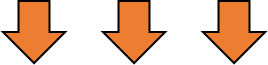

In [18]:
parame = ['turb', 'cond', 'pH']
# We are going to use 3 splits: 0 (maybe 1), 2.5 and 5%
threshold_range_relative = [0.01, 0.025, 0.05]
threshold_range = [threshold_range_relative, threshold_range_relative, threshold_range_relative]
if normalized == False:
    threshold_range_original = []
    for par in parame:     
        threshold_range_original.append([scale_threshold_back(thr, par, info=True) for thr in threshold_range[0]])
    threshold_range = threshold_range_original

Threshold in original turb units: 17.699
Threshold in original turb units: 44.247
Threshold in original turb units: 88.493
Threshold in original cond units: 6.193
Threshold in original cond units: 15.483
Threshold in original cond units: 30.966
Threshold in original pH units: 0.033
Threshold in original pH units: 0.083
Threshold in original pH units: 0.165


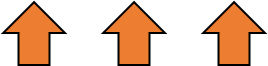

In [19]:
def range_variance_visual_assessment(lag, gap, threshold, param):
    # Create a figure and a 2x4 grid of subplots
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()  # Flatten the array of axes for easy iteration
    
    for eve in range(8):
        # Getting range variance 
        number_of_instances = (len(multipar_test_dataset_list[eve][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * lag) - gap + 1
        eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)[eve]
        range_variance = clustering_instances_event(eve_inst_array, number_of_instances, threshold)
    
        # Example data
        categories = np.arange(number_of_instances)
        values = range_variance[1].reshape(1, len(range_variance[1]))[0]

        # Defining condition
        condition = np.array(values) < threshold
        
        # Define colors based on condition
        colors = np.where(condition, 'red', 'green')
        
        # Plot the data
        ax = axes[eve]
        ax.bar(categories, values, color=colors)
        ax.axhline(y=threshold, color='r', linestyle='--')
        
        # Add a legend
        ax.legend(handles=[plt.Line2D([0], [0], color='green', lw=4, label=f'Range >= {threshold:.03f}'),
                           plt.Line2D([0], [0], color='red', lw=4, label=f'Range < {threshold:.03f}')],
                           loc='upper right')
    
        
        # Add labels and title
        ax.set_title(f'Test dataset, event {eve+1}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('Range value')
        # ax.set_ylim(0, 0.2)

    # Add a common title for the entire figure
    fig.suptitle(f'Range Variance Visual Assessment for {gap/2} min  gap\n', fontsize=16)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Display the figure
    plt.show()

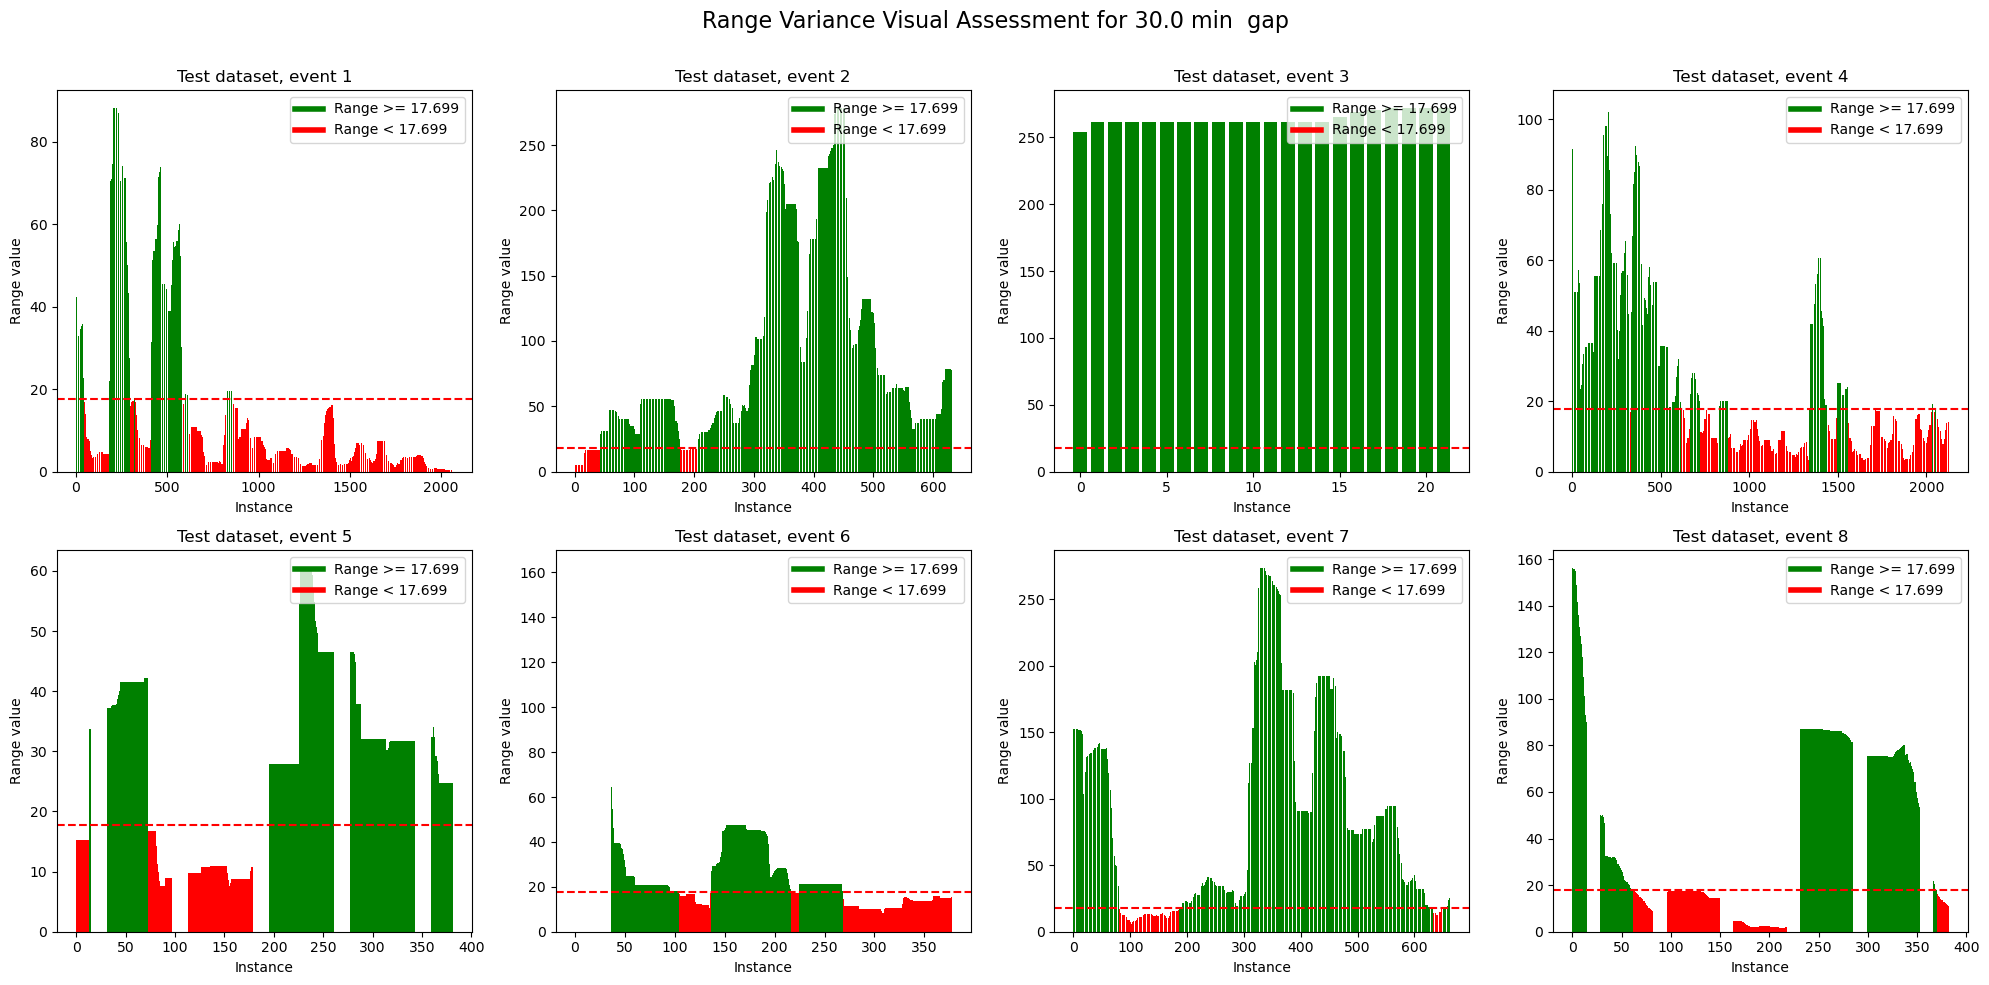

In [20]:
# Uncomment to visualize if needed

range_variance_visual_assessment(20, 60, threshold_range[0][0], parame[0])
# range_variance_visual_assessment(20, 40, threshold_range[0][0], parame[0])
# range_variance_visual_assessment(20, 20, threshold_range[0][0], parame[0])

### Calculating all metric lists for the plots and models evaluation

In [21]:
# Function to extract the lists of metrics separately to two variables - one for per-event list, another for total model scores and then making two separate dictionaries for different metrics
def per_event_and_total_metrics(metric_functions, benchmark, event_list=None, l_g_list=None, forecast=None, case_list=None, param=None, clustering=None, threshold=None):
    # Creating dictionaries to store each element of the tuple separately

    # Create a dictionary to map each parameter to its corresponding index
    par_map = {'turb': 0,'cond': 1,'pH': 2}

    metrics_event_list, metrics_total_list = [], []
    # Iterating over three different splits
    for thr in threshold[par_map[param]]:
        metric_first_element, metric_second_element = {}, {}
        for metric_name in metric_functions:
            # Call the function and unpack the returned tuple
            if benchmark == True:
                first, second = metrics_benchmark(event_list, metric_name, l_g_list, param, clustering, thr)
            elif benchmark == False:
                first, second = metric_event_model(event_list, forecast, case_list, metric_name, param, clustering, thr)
            
            # Store the results in their respective dictionaries
            metric_first_element[metric_name] = first
            metric_second_element[metric_name] = second
        metrics_event_list.append(metric_first_element)
        metrics_total_list.append(metric_second_element)

    return metrics_event_list, metrics_total_list

In [22]:
%%time
# For all instances, regardless variance of the instances

# turb_metric_event_base_test, turb_metric_event_base_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering=None, threshold=threshold_range)
# turb_metric_event_test, turb_metric_event_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=turb_forecast_test, case_list=turb_case_list,  param='turb', clustering=None, threshold=threshold_range)
# cond_metric_event_base_test, cond_metric_event_base_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=cond_l_g_list,  param='cond', clustering=None, threshold=threshold_range)
# cond_metric_event_test, cond_metric_event_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=cond_forecast_test, case_list=cond_case_list,  param='cond', clustering=None, threshold=threshold_range)
# pH_metric_event_base_test, pH_metric_event_base_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=pH_l_g_list,  param='pH', clustering=None, threshold=threshold_range)
# pH_metric_event_test, pH_metric_event_test_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=pH_forecast_test, case_list=pH_case_list,  param='pH', clustering=None, threshold=threshold_range)


# # turb_metric_event_base_train, turb_metric_event_base_train_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_train_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering=None, threshold=threshold_range)
# # turb_metric_event_train, turb_metric_event_train_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_train_dataset_list, forecast=turb_forecast_train, case_list=turb_case_list,  param='turb', clustering=None, threshold=threshold_range)

print('Done')

# # Only for the instances with HIGH variance

turb_metric_event_base_test_hv, turb_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering='High variance', threshold=threshold_range)
turb_metric_event_test_hv, turb_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=turb_forecast_test, case_list=turb_case_list,  param='turb', clustering='High variance', threshold=threshold_range)
# cond_metric_event_base_test_hv, cond_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=cond_l_g_list,  param='cond', clustering='High variance', threshold=threshold_range)
# cond_metric_event_test_hv, cond_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=cond_forecast_test, case_list=cond_case_list,  param='cond', clustering='High variance', threshold=threshold_range)
# pH_metric_event_base_test_hv, pH_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=pH_l_g_list,  param='pH', clustering='High variance', threshold=threshold_range)
# pH_metric_event_test_hv, pH_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=pH_forecast_test, case_list=pH_case_list,  param='pH', clustering='High variance', threshold=threshold_range)

# # turb_metric_event_base_train_hv, turb_metric_event_base_train_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_train_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering='High variance', threshold=threshold_range)
# # turb_metric_event_train_hv, turb_metric_event_train_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_train_dataset_list, forecast=turb_forecast_train, case_list=turb_case_list,  param='turb', clustering='High variance', threshold=threshold_range)

print('Done')

# # Only for the instances with LOW variance

# turb_metric_event_base_test_lv, turb_metric_event_base_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering='Low variance', threshold=threshold_range)
# turb_metric_event_test_lv, turb_metric_event_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=turb_forecast_test, case_list=turb_case_list,  param='turb', clustering='Low variance', threshold=threshold_range)
# cond_metric_event_base_test_lv, cond_metric_event_base_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=cond_l_g_list,  param='cond', clustering='Low variance', threshold=threshold_range)
# cond_metric_event_test_lv, cond_metric_event_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=cond_forecast_test, case_list=cond_case_list,  param='cond', clustering='Low variance', threshold=threshold_range)
# pH_metric_event_base_test_lv, pH_metric_event_base_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=pH_l_g_list,  param='pH', clustering='Low variance', threshold=threshold_range)
# pH_metric_event_test_lv, pH_metric_event_test_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=pH_forecast_test, case_list=pH_case_list,  param='pH', clustering='Low variance', threshold=threshold_range)


# # turb_metric_event_base_train_lv, turb_metric_event_base_train_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_train_dataset_list,  l_g_list=turb_l_g_list,  param='turb', clustering='Low variance', threshold=threshold_range)
# # turb_metric_event_train_lv, turb_metric_event_train_lv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_train_dataset_list, forecast=turb_forecast_train, case_list=turb_case_list,  param='turb', clustering='Low variance', threshold=threshold_range)

print('Done')

Done
Done
Done
CPU times: total: 1min 25s
Wall time: 1min 26s


### Heatmaps

#### Interactive heatmap for each test case

In [23]:
def data_for_heatmap(l, g, cfg_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name):
    models_list = [metric_event[metric_name][case[1]] for case in available_models(l, g, cfg_list)]
    models_list_total = [metric_event_total[metric_name][case[1]] for case in available_models(l, g, cfg_list)]
    base_list = metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]]
    base_list_total = [metric_event_base_total[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]]]

    # List of names for the columns of the heatmap
    model_list_names = [case[0] for case in available_models(l, g, cfg_list)]
    
    model_list_names = ['LSTM NN' if 'LSTM' in model_name else model_name for model_name in model_list_names]
    model_list_names = ['MLP NN' if 'MLP' in model_name else model_name for model_name in model_list_names]
    model_list_names = ['CNN' if 'CNN' in model_name else model_name for model_name in model_list_names]
    
    # Merging lists
    compl_list = np.transpose(np.array(models_list + base_list))
    compl_list_total = np.transpose(np.array(models_list_total + base_list_total))
    compl_list_names = model_list_names + ['Linear interpolation']

    return compl_list, compl_list_total, compl_list_names

In [24]:
def collection_of_calculated_metrics(parameter, clustering, dataset, threshold):
    if parameter == 'Turbidity':
        if dataset == 'Test':
            if clustering == 'All values':
                metric_event_base = turb_metric_event_base_test
                metric_event_base_total = turb_metric_event_base_test_total
                metric_event = turb_metric_event_test
                metric_event_total = turb_metric_event_test_total
                    
            elif dataset == 'Train':
                metric_event_base = turb_metric_event_base_train
                metric_event_base_total = turb_metric_event_base_train_total
                metric_event = turb_metric_event_train
                metric_event_total = turb_metric_event_train_total

            
            elif clustering == 'High variance':
                metric_event_base = turb_metric_event_base_test_hv
                metric_event_base_total = turb_metric_event_base_test_hv_total
                metric_event = turb_metric_event_test_hv
                metric_event_total = turb_metric_event_test_hv_total
                    
                    
            elif dataset == 'Train':
                metric_event_base = turb_metric_event_base_train_hv
                metric_event_base_total = turb_metric_event_base_train_hv_total
                metric_event = turb_metric_event_train_hv
                metric_event_total = turb_metric_event_train_hv_total


            elif clustering == 'Low variance':
                metric_event_base = turb_metric_event_base_test_lv
                metric_event_base_total = turb_metric_event_base_test_lv_total
                metric_event = turb_metric_event_test_lv
                metric_event_total = turb_metric_event_test_lv_total
                    
                    
            elif dataset == 'Train':
                metric_event_base = turb_metric_event_base_train_lv
                metric_event_base_total = turb_metric_event_base_train_lv_total
                metric_event = turb_metric_event_train_lv
                metric_event_total = turb_metric_event_train_lv_total



    elif parameter == 'Conductivity':
        if clustering == 'All values':
            if dataset == 'Test':
                metric_event_base = cond_metric_event_base_test
                metric_event_base_total = cond_metric_event_base_test_total
                metric_event = cond_metric_event_test
                metric_event_total = cond_metric_event_test_total

                    
            elif dataset == 'Train':
                metric_event_base = cond_metric_event_base_train
                metric_event_base_total = cond_metric_event_base_train_total
                metric_event = cond_metric_event_train
                metric_event_total = cond_metric_event_train_total


        elif clustering == 'High variance':
            if dataset == 'Test':
                metric_event_base = cond_metric_event_base_test_hv
                metric_event_base_total = cond_metric_event_base_test_hv_total
                metric_event = cond_metric_event_test_hv
                metric_event_total = cond_metric_event_test_hv_total

                    
            elif dataset == 'Train':
                metric_event_base = cond_metric_event_base_train_hv
                metric_event_base_total = cond_metric_event_base_train_hv_total
                metric_event = cond_metric_event_train_hv
                metric_event_total = cond_metric_event_train_hv_total


        elif clustering == 'Low variance':
            if dataset == 'Test':
                metric_event_base = cond_metric_event_base_test_lv
                metric_event_base_total = cond_metric_event_base_test_lv_total
                metric_event = cond_metric_event_test_lv
                metric_event_total = cond_metric_event_test_lv_total

                    
            elif dataset == 'Train':
                metric_event_base = cond_metric_event_base_train_lv
                metric_event_base_total = cond_metric_event_base_train_lv_total
                metric_event = cond_metric_event_train_lv
                metric_event_total = cond_metric_event_train_lv_total

                
    elif parameter == 'pH':
        if dataset == 'Test':
            if clustering == 'All values':
                metric_event_base = pH_metric_event_base_test
                metric_event_base_total = pH_metric_event_base_test_total
                metric_event = pH_metric_event_test
                metric_event_total = pH_metric_event_test_total
                    
            elif dataset == 'Train':
                metric_event_base = pH_metric_event_base_train
                metric_event_base_total = pH_metric_event_base_train_total
                metric_event = pH_metric_event_train
                metric_event_total = pH_metric_event_train_total

            
            elif clustering == 'High variance':
                metric_event_base = pH_metric_event_base_test_hv
                metric_event_base_total = pH_metric_event_base_test_hv_total
                metric_event = pH_metric_event_test_hv
                metric_event_total = pH_metric_event_test_hv_total
                    
                    
            elif dataset == 'Train':
                metric_event_base = pH_metric_event_base_train_hv
                metric_event_base_total = pH_metric_event_base_train_hv_total
                metric_event = pH_metric_event_train_hv
                metric_event_total = pH_metric_event_train_hv_total


            elif clustering == 'Low variance':
                metric_event_base = pH_metric_event_base_test_lv
                metric_event_base_total = pH_metric_event_base_test_lv_total
                metric_event = pH_metric_event_test_lv
                metric_event_total = pH_metric_event_test_lv_total
                    
                    
            elif dataset == 'Train':
                metric_event_base = pH_metric_event_base_train_lv
                metric_event_base_total = pH_metric_event_base_train_lv_total
                metric_event = pH_metric_event_train_lv
                metric_event_total = pH_metric_event_train_lv_total

    return metric_event_base[threshold], metric_event_base_total[threshold], metric_event[threshold], metric_event_total[threshold]

In [25]:
def heatmap(l, g, parameter, dataset, metric_name, clustering, threshold):
    if dataset == 'Test':
        plotsize = (12, 6)
    elif dataset == 'Train':
        plotsize = (16, 16)

    if parameter == 'Turbidity':
        case_list = turb_case_list
        l_g_list = turb_l_g_list
    elif parameter == 'Conductivity':
        case_list = cond_case_list
        l_g_list = cond_l_g_list
    elif parameter == 'pH':
        case_list = pH_case_list
        l_g_list = pH_l_g_list
    
    # Create a dictionary to map each parameter to its corresponding index
    par_map = {
        'Turbidity': (0, turb_case_list, turb_l_g_list),
        'Conductivity': (1, cond_case_list, cond_l_g_list),
        'pH': (2, pH_case_list, pH_l_g_list)
    }

    par_col, case_list, l_g_list = par_map.get(parameter, (None, None, None))
    
    threshold_mapping = {
    f'{threshold_range[par_col][0]}': 0,
    f'{threshold_range[par_col][1]}': 1,
    f'{threshold_range[par_col][2]}': 2
    }

    thr = threshold_mapping.get(threshold)

    # Taking collections of metrics corresponding to the chosen parameters on the interactive plot
    metric_event_base, metric_event_base_total, metric_event, metric_event_total = collection_of_calculated_metrics(parameter, clustering, dataset, thr)
    
    # data for the plot
    compl_list, compl_list_total, compl_list_names = data_for_heatmap(l, g, case_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name)

    t_coeff = 0.5    # 1 min = 2 datapoints
    
    fig = plt.figure(figsize=plotsize)

    # Create the heatmap
    plt.imshow(compl_list, cmap='viridis_r', vmin = 0)
    cbar = plt.colorbar()  # Add color bar to show scale
    cbar.set_label(f'{metric_name}', fontsize = 12)
    
    # Add annotations to each cell
    for i in range(len(compl_list)):
        for j in range(len(compl_list[i])):
            plt.text(j, i, f'{compl_list[i][j]:.3f}', ha='center', va='center', color='white')


    # Update x labels to include the column averages
    updated_x_labels = [f'{label}\nAvg. score: {avg:.3f}' for label, avg in zip(compl_list_names, compl_list_total)]
    
    # Manually label every column
    plt.xticks(ticks=np.arange(compl_list.shape[1]), labels=updated_x_labels, rotation=90, fontsize = 9)
    
    # Show every y tick not every second
    plt.yticks(ticks=np.arange(compl_list.shape[0]))
    
    # Show the plot
    plt.xlabel('\nModels', fontsize = 12)
    plt.ylabel('Events', fontsize = 12)
    plt.title(f'\nContext size = 2 x {round(t_coeff * l, 1)} min, gap size = {round(t_coeff * g)} min\n', fontsize = 14)
    plt.show()

In [26]:
# General widget display settings
item_layout = Layout(display='flex', flex_flow='column', align_items='center', width='100%')

# Parameter
par_hm = ToggleButtons(options = ['Turbidity', 'Conductivity', 'pH'], description = 'Parameter:', value = 'Turbidity', button_style = 'info')

# Dataset
dataset_hm = ToggleButtons(options = ['Test', 'Train'], description = 'Dataset:', value = 'Test', button_style = 'info')

# Lag and gap sizes
l_size_hm = Dropdown(options = turb_unique_lag_list, description = 'l_s:')
g_size_hm = Dropdown(options = turb_unique_gap_list, description = 'g_s:')

# Choosing metric
metr_hm = ToggleButtons(options = list(metric_functions.keys()), description = 'Metric name:', button_style = 'info')

# Variance
clustering_hm = ToggleButtons(options = ['All values', 'High variance', 'Low variance'], description = 'Variancy:', value = 'High variance', button_style = 'info')

threshold_hm = ToggleButtons(options = [f'{threshold_range[0][0]}', f'{threshold_range[0][1]}', f'{threshold_range[0][2]}'], description = 'Split:', value = f'{threshold_range[0][2]}', button_style = 'info')

# Interaction of dependent widgets
# This function updates lists of l and g to match the available ones for given parameter
def update_l_g(*args):
    if par_hm.value == 'Turbidity':
        l_size_hm.options = turb_unique_lag_list
        g_size_hm.options = turb_unique_gap_list
    elif par_hm.value == 'Conductivity':
        l_size_hm.options = cond_unique_lag_list
        g_size_hm.options = cond_unique_gap_list
    elif par_hm.value == 'pH':
        l_size_hm.options = pH_unique_lag_list
        g_size_hm.options = pH_unique_gap_list

# Observes l_size and g_size in order to update configuration
par_hm.observe(update_l_g)

In [27]:
print()
# Widget display settings
wz = ipywidgets.HBox([par_hm, dataset_hm, l_size_hm, g_size_hm, metr_hm, clustering_hm, threshold_hm], layout=item_layout)

heatmap_widget = ipywidgets.interactive_output(heatmap, {'parameter': par_hm, 'dataset': dataset_hm, 'l': l_size_hm, 'g': g_size_hm, 'metric_name': metr_hm, 'clustering': clustering_hm, 'threshold': threshold_hm})

# Plot display settings
heatmap_widget.layout.display='flex'
heatmap_widget.layout.justify_content='center'
display(wz, heatmap_widget)

Output(layout=Layout(display='flex', justify_content='center'))

#### Heatmaps of average scores for the model accross different model structures

In [28]:
def total_model_metrics(l, g, parameter, dataset, metric_name, clustering, threshold):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (turb_case_list, turb_l_g_list),
        'Conductivity': (cond_case_list, cond_l_g_list),
        'pH': (pH_case_list, pH_l_g_list)
    }
    
    # Retrieve the corresponding lists using the parameter
    case_list, l_g_list = param_mapping.get(parameter, (None, None))

    # Taking collections of metrics corresponding to the chosen parameters on the interactive plot
    metric_event_base, metric_event_base_total, metric_event, metric_event_total = collection_of_calculated_metrics(parameter, clustering, dataset, threshold)

    # data for the plot
    compl_list, compl_list_total, compl_list_names = data_for_heatmap(l, g, case_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name)

    return [compl_list_total, compl_list_names]


def total_metrics_list(total_metrics, model_name):
    # Extracting values
    values = []
    
    for item in total_metrics:
        value_array = item[0]
        methods = item[1]
        if model_name in methods:
            # Find the index
            index = methods.index(model_name)
            # Extract the value corresponding to 'model's name'
            values.append(value_array[index])
        else:
            # While training, as not all models are are there yet
            values.append(np.nan)
    return values

# Function to generate heatmap data
def generate_heatmap_data(l_g_list, total_metrics):
    # Extract all gap and lag values and transform them into minutes
    gap_values = [x / 2 for x in sorted(set(entry[0] for entry in l_g_list))]
    lag_values = [x / 2 for x in sorted(set(entry[1] for entry in l_g_list))]
    
    # Create index mappings
    x_map = {value: idx for idx, value in enumerate(gap_values)}
    y_map = {value: idx for idx, value in enumerate(lag_values)}
    
    heatmap_data = np.zeros((len(gap_values), len(lag_values)))
    for lag_gap, metric in zip([x / 2 for x in l_g_list], total_metrics):
        heatmap_data[x_map[lag_gap[0]], y_map[lag_gap[1]]] = metric
    return heatmap_data

def heatmap_model_datasets(parameter, dataset, metric_name, clustering, threshold):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (turb_case_list, turb_l_g_list),
        'Conductivity': (cond_case_list, cond_l_g_list),
        'pH': (pH_case_list, pH_l_g_list)
    }
    
    # Retrieve the corresponding lists using the parameter
    case_list, l_g_list = param_mapping.get(parameter, (None, None))
        
    total_metrics = [total_model_metrics(l, g, parameter, dataset, metric_name, clustering, threshold) for l, g in zip(l_g_list[:, 0], l_g_list[:, 1])]
    
    total_metrics_lstm = total_metrics_list(total_metrics, 'LSTM NN')
    total_metrics_cnn = total_metrics_list(total_metrics, 'CNN')
    total_metrics_mlp = total_metrics_list(total_metrics, 'MLP NN')
    total_metrics_linear = total_metrics_list(total_metrics, 'Linear interpolation')
    
    # Generate heatmap data for each model
    heatmap_data_lstm = generate_heatmap_data(l_g_list, total_metrics_lstm)
    heatmap_data_cnn = generate_heatmap_data(l_g_list, total_metrics_cnn)
    heatmap_data_mlp = generate_heatmap_data(l_g_list, total_metrics_mlp)
    heatmap_data_linear = generate_heatmap_data(l_g_list, total_metrics_linear)
    # List of heatmap data
    return [heatmap_data_lstm, heatmap_data_cnn, heatmap_data_mlp, heatmap_data_linear]

# Create color data arrays for each heatmap
def create_color_data(heatmap_data_lstm, heatmap_data_cnn, heatmap_data_mlp, heatmap_data_linear):
    num_rows, num_cols = heatmap_data_lstm.shape
    color_data_lstm = np.zeros_like(heatmap_data_lstm, dtype=int)
    color_data_cnn = np.zeros_like(heatmap_data_cnn, dtype=int)
    color_data_mlp = np.zeros_like(heatmap_data_mlp, dtype=int)
    color_data_linear = np.zeros_like(heatmap_data_linear, dtype=int)
    
    for i in range(num_rows):
        for j in range(num_cols):
            # Three values of the three heatmaps
            values = [heatmap_data_lstm[i, j], heatmap_data_cnn[i, j], heatmap_data_mlp[i, j], heatmap_data_linear[i, j]]
            # Also them but identified as min max and median
            min_val = np.nanmin(values)
            
            color_data_mapping = [color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear]
            
            for k, color_data in enumerate(color_data_mapping):
                color_data[i, j] = 2 if values[k] == min_val else 1  # 2 for Green, 1 for Red

    return color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear

# Custom colormap
def create_custom_colormap():
    return mcolors.ListedColormap(['red', 'green'])

def heatmaps_models(parameter, dataset, metric_name, clustering, colormap):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (0, turb_case_list, turb_l_g_list),
        'Conductivity': (1, cond_case_list, cond_l_g_list),
        'pH': (2, pH_case_list, pH_l_g_list)
    }
    
    # Retrieve the corresponding lists using the parameter
    par_col, case_list, l_g_list = param_mapping.get(parameter, (None, None, None))
    
    # Getting datasets for 3 splits
    heatmap_datasets = [heatmap_model_datasets(parameter, dataset, metric_name, clustering, thr) for thr in range(len(threshold_range[par_col]))]
    # Getting maximum value for v_max of c_bar
    heatmap_datasets_max = np.max([np.max(arr) for inner_list in heatmap_datasets for arr in inner_list])
    
    # Color data arrays
    color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear = [], [], [], []
    for split in heatmap_datasets:
        cd_lstm, cd_cnn, cd_mlp, cd_linear = create_color_data(split[0], split[1], split[2], split[3])
        color_data_lstm.append(cd_lstm)
        color_data_cnn.append(cd_cnn)
        color_data_mlp.append(cd_mlp)
        color_data_linear.append(cd_linear)

    # List of heatmap colors data
    color_datasets = [color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear]
    
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))

    # Titles for each subplot
    titles = ['LSTM NN', 'CNN', 'MLP NN', 'Linear interpolation \n(benchmark)']

    if colormap == 'Not compared':
        for i, threshold in enumerate(threshold_range[par_col]):
            # Plot each heatmap for the current threshold
            for j, (ax, data, title) in enumerate(zip(axes[i], heatmap_datasets[i], titles)):
                # Transposing data for better visualisation
                data = np.transpose(data)[::-1]
                
                formatted_heatmap_data = np.array([[f"{cell:.2f}" for cell in row] for row in data])
                sns.heatmap(data, linewidths=0.5, linecolor='black', cmap='viridis_r', annot=formatted_heatmap_data, fmt='', ax=ax, cbar=False, vmin=0, vmax = heatmap_datasets_max)
                ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                ax.tick_params(top=False, bottom=False, left=False, right=False)
                
                # Getting rid of redundant stuff on vertical axis
                if i == 0:
                    ax.set_title(f'\n{title}\n', fontsize=14)
                    ax.set_xticklabels([])
                elif i == 1:
                    ax.set_xticklabels([])
                elif i == 2:
                    ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                    
                # Getting rid of redundant stuff on horizontal axis
                if j == 0:
                    ax.set_ylabel(f'{100 * threshold_range_relative[i]} % split                                ', rotation='horizontal', fontsize=12)
                    ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                else:
                    ax.set_yticklabels([])

        # Determine the colormap and range
        cbar_ax = fig.add_axes([0.95, 0.11, 0.03, 0.69])  # Adjust position as needed
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=0, vmax=heatmap_datasets_max)), cax=cbar_ax)
        cb.set_label(f'\n{metric_name}', fontsize = 12)

    
    elif colormap == 'Compared':
        for i, threshold in enumerate(threshold_range[par_col]):
            # Plot each heatmap for the current threshold
            for j, (ax, data, color_data, title) in enumerate(zip(axes[i], heatmap_datasets[i], color_datasets, titles)):
                # Transposing data for better visualisation
                data = np.transpose(data)[::-1]
                color_data = np.transpose(color_data[i])[::-1]
                sns.heatmap(color_data, linewidths=0.5, linecolor='black', cmap=create_custom_colormap(), annot=np.array([[f"{cell:.2f}" if not np.isnan(cell) else '' for cell in row] for row in data]), fmt='', ax=ax, cbar=False, vmin=0, vmax=3)
                ax.tick_params(top=False, bottom=False, left=False, right=False)

                # Getting rid of redundant stuff on vertical axis
                if i == 0:
                    ax.set_title(f'\n{title}\n', fontsize=14)
                    ax.set_xticklabels([])
                elif i == 1:
                    ax.set_xticklabels([])
                elif i == 2:
                    ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                    
                # Getting rid of redundant stuff on horizontal axis
                if j == 0:
                    ax.set_ylabel(f'{100 * threshold_range_relative[i]} % split                                ', rotation='horizontal', fontsize=12)
                    ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                else:
                    ax.set_yticklabels([])
                    
    
        # Add a colorbar with custom ticks
        cbar_ax = fig.add_axes([0.95, 0.4, 0.04, 0.1])
        norm = mcolors.Normalize(vmin=0, vmax=3)
        cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=create_custom_colormap()), cax=cbar_ax)
        cb.set_ticks([0.8, 2.2])
        cb.set_ticklabels(['Rest', 'Best'])
        cb.ax.tick_params(top=False, bottom=False, left=False, right=False)

    # Add one common x-axis label for all graphs
    fig.text(0.5, 0.06, 'Context size x 2, min', ha='center', fontsize=12)
    fig.text(0.09, 0.46, 'Gaps, min', ha='center', va='center', rotation='vertical', fontsize=12)
    
    # Add total figure title
    fig.suptitle(f'\n{parameter}', fontsize=18, y=0.95)
    # Show the combined figure
    plt.subplots_adjust(hspace=0.02, top=0.8)  # Set the vertical space between subplots to zero
    plt.show()

In [29]:
# Parameter
par_hm_m = ToggleButtons(options = ['Turbidity', 'Conductivity', 'pH'], description = 'Parameter:', value = 'Turbidity', button_style = 'info')

# Dataset
dataset_hm_m = ToggleButtons(options = ['Test', 'Train'], description = 'Dataset:', value = 'Test', button_style = 'info')

# Choosing metric
metr_hm_m = ToggleButtons(options = list(metric_functions.keys()), description = 'Metric name:', button_style = 'info')

# Variance
clustering_hm_m = ToggleButtons(options = ['All values', 'High variance', 'Low variance'], description = 'Variancy:', value = 'High variance', button_style = 'info')

colormap_hm_m = ToggleButtons(options = ['Compared', 'Not compared'], description = 'Colormap:', value = 'Compared', button_style = 'info')

In [30]:
print()
# Widget display settings
wz_m = ipywidgets.HBox([par_hm_m, dataset_hm_m, metr_hm_m, clustering_hm_m, colormap_hm_m], layout=item_layout)

heatmap_m_widget = ipywidgets.interactive_output(heatmaps_models, {'parameter': par_hm_m, 'dataset': dataset_hm_m, 'metric_name': metr_hm_m, 'clustering':clustering_hm_m, 'colormap': colormap_hm_m})

# Plot display settings
heatmap_m_widget.layout.display='flex'
heatmap_m_widget.layout.justify_content='center'
display(wz_m, heatmap_m_widget)

Output(layout=Layout(display='flex', justify_content='center'))

### Interactive forecast plot (FOR CORRECT DISPLAY OF THE PLOT, DATASET MUST BE NORMALIZED)

In [259]:
def plot_series(x, y, format=('-', '-'), start=None, end=None, x_name='Time', y_name='Value', title=None, label=None):
    '''
    Visualizes time series data

    Args:
      x (array of int) - contains indeces
      y (array) - contains the measurements for each time step
      format - line style when plotting the graph
      start - first time step to plot
      end - last time step to plot
    '''
    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))
    
    n = 0
    for x_n, y_n in zip(x, y):
        # Plot the time series data for each of the curves consequently
        plt.plot(x_n, y_n, format[n], label=label[n] if label else None)
        n += 1

    # Legend
    plt.legend()
    
    # Title
    plt.title(title)
    
    # Label the x-axis
    plt.xlabel(x_name)

    # Label the y-axis
    plt.ylabel(y_name)

    # Overlay a grid on the graph
    plt.grid(True)
    
    # For plotting only part of the graph
    if start != None or end != None:
        plt.gca().set_xlim(start, end)
    
    # Draw the graph on screen
    plt.show()

In [260]:
def interactive_plot(parameter, dataset_name, l, g, case_ind, n_event, instance, time_axis, zoom, metric_name, selected_params):
    if parameter == 'Turbidity':
        param = 'turb'
        l_g_list = turb_l_g_list
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = turb_forecast_test
            metric_event = turb_metric_event_test
            metric_event_base = turb_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = turb_forecast_train
            metric_event = turb_metric_event_train
            metric_event_base = turb_metric_event_base_train
            
    elif parameter == 'Conductivity':
        param = 'cond'
        l_g_list = cond_l_g_list        
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = cond_forecast_test
            metric_event = cond_metric_event_test
            metric_event_base = cond_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = cond_forecast_train
            metric_event = cond_metric_event_train
            metric_event_base = cond_metric_event_base_train           

    elif parameter == 'pH':
        param = 'pH'
        l_g_list = pH_l_g_list
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = pH_forecast_test
            metric_event = pH_metric_event_test
            metric_event_base = pH_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = pH_forecast_train
            metric_event = pH_metric_event_train
            metric_event_base = pH_metric_event_base_train


    
    # Initializer is the index of the beginning of the lag preceeding the gap
    y, linear_int, pr_w, suc_w, initializer = instance_event_collection(l, g, dataset_list, param, base=True)[n_event][instance]

    # Column indeces of the parameters in the datasets
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8, 'Absolute_gradient_of_flow_ls':9}
    par_col = param_columns[param]
    
    # Lag the event
    dataset = dataset_list[n_event][predefined_max_lag_size: -(predefined_max_lag_size)]
    
    # Choosing only parameters that have been chosen
    extended_dataset = dataset[:, selected_params]
    # Labels for chosen parameters from the extended dataset
    labels = [['Conductivity', 'Temperature', 'DO', 'Turbidity', 'pH', 'Flow', 'Cumulative discharge', 'Time since last rain', 'Time since rain started', 'Absolute gradient of flow l/s'][p] for p in selected_params]
    
    # Time axis
    if time_axis == 'datapoints':
        t_coeff = 1
        x_name = 'Datapoint index'
    elif time_axis == 'minutes':
        t_coeff = 0.5    # 5 min = 10 datapoints
        x_name = 'Time (min)'

    # The whole duration of the event from the test dataset
    time_event = t_coeff * np.arange(len(extended_dataset))
    # Placing the forecast to where it belongs on the plot
    time_forecast = t_coeff * np.arange(initializer + l, initializer + l + g)
    # Input times
    time_pr_w = t_coeff * np.arange(initializer, initializer + l)

    time_suc_w = t_coeff * np.arange(initializer + l + g, initializer + 2 * l + g)

    # Zooming in the graph
    if zoom == 'Off':
        start = None
        end = None
    elif zoom == 'On':
        start = t_coeff * (initializer - l)
        end = t_coeff * (initializer + 3 * l + g)
    
    plot_series(x = (time_pr_w, time_forecast, time_forecast, time_suc_w, time_event),
            y = (pr_w, forecast[case_ind][n_event][instance][l:l+g], linear_int, suc_w, extended_dataset),
            format = ('rx', '--r','--g', 'rx', '-'),
            x_name = x_name,
            y_name = 'Scaled parameters',
            label = ('Input', 'Forecast', 'Linear interpolation', 'Input', labels),
            title = f'{dataset_name} dataset, event № {n_event}', 
            start = start,
            end = end)
    plt.show()
    
    # metric score summary
    print(f'\033[1m{metric_name} score summary:\033[0m\n')

    print(f'model:                                 for the current instance - \033[1m{metric_functions[metric_name](y, forecast[case_ind][n_event][instance][l:l+g].squeeze()):.4f}\033[0m')
          # f'| average per event - \033[1m{metric_event[metric_name][case_ind][n_event]:.4f}\033[0m',
          # f'| overall model score - \033[1m{np.mean(metric_event[metric_name][case_ind]):.4f}\033[0m')
    print(f'Linear interpolation:             for the current instance - \033[1m{metric_functions[metric_name](y, linear_int):.4f}\033[0m')
          # f'| average per event - \033[1m{metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]][0][n_event]:.4f}\033[0m',
          # f'| overall model score - \033[1m{np.mean(metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]][0]):.4f}\033[0m')

In [261]:
# Widgets
# Parameter
par = ToggleButtons(options = ['Turbidity', 'Conductivity', 'pH'], description = 'Parameter:', value = 'Turbidity', button_style = 'info')
# Dataset
dset = ToggleButtons(options = ['Test', 'Train'], description = 'Dataset:', value = 'Test', button_style = 'info')
# Lag and gap sizes
l_size = Dropdown(options = turb_unique_lag_list, description = 'Lag size:')
g_size = Dropdown(options = turb_unique_gap_list, description = 'Gap size:')
# Model configuration
config = Dropdown(options = available_models(turb_unique_lag_list[0], turb_unique_gap_list[0], turb_case_list), description = 'Model:')
# Event number
event = Dropdown(options = list(range(len(multipar_test_dataset_list))), value = 0, description = 'Event №:')
# Number of the gaps that can be instantionized for given model
inst = IntSlider(min=0, max=len(multipar_test_dataset_list[0][predefined_max_lag_size: -(predefined_max_lag_size)])  - 2 * turb_unique_lag_list[0] - turb_unique_gap_list[0], step = 1, value = 0, readout_format = 'd', description = 'Instance:')
# Button for switching between time units
time_ax = ToggleButtons(options = ['datapoints', 'minutes'], description = 'Time axis', button_style = 'info')
# Buttons for zomming
zoom_in = ToggleButtons(options = ['Off', 'On'], description = 'Zoom', button_style = 'info')
# Choosing metric
metr = ToggleButtons(options = list(metric_functions.keys()), description = 'Metric name:', button_style = 'info')


# Define parameters and their corresponding numbers
parameters = {'Conductivity':0, 'Temperature':1, 'DO':2, 'Turbidity':3, 'pH':4, 'Flow':5, 'Cumulative discharge':6, 'Time since last rain':7, 'Time since rain started':8, 'Absolute gradient of flow l/s':9}

# Create checkbox widgets for each parameter
checkboxes = {param: ipywidgets.Checkbox(description=param, value=False) for param in parameters}

# Create a button widget to submit the selection
submit_button = ipywidgets.Button(description="Submit")

# Create a fixed widget to hold the selected parameters
selected_parameters_widget = ipywidgets.fixed([])

# Interaction of dependent widgets
# Function to collect selected parameters
def collect_selected_parameters(button):
    selected_parameters = [parameters[param] for param, checkbox in checkboxes.items() if checkbox.value]
    # Update the fixed widget
    selected_parameters_widget.value = selected_parameters

# Attach the function to the button's click event
submit_button.on_click(collect_selected_parameters)

# This function updates lists of l and g to match the available ones for given parameter
def update_l_g_lists(*args):
    if par.value == 'Turbidity':
        l_size.options = turb_unique_lag_list
        g_size.options = turb_unique_gap_list
    elif par.value == 'Conductivity':
        l_size.options = cond_unique_lag_list
        g_size.options = cond_unique_gap_list
    elif par.value == 'pH':
        l_size.options = pH_unique_lag_list
        g_size.options = pH_unique_gap_list

# Observes l_size and g_size in order to update configuration
par.observe(update_l_g_lists)

# This function updates list of configurations depending on lag and gap sizes
def update_case_list(*args):
    if par.value == 'Turbidity':
        config.options = available_models(l_size.value, g_size.value, turb_case_list)
    elif par.value == 'Conductivity':
        config.options = available_models(l_size.value, g_size.value, cond_case_list)
    elif par.value == 'pH':
        config.options = available_models(l_size.value, g_size.value, pH_case_list)

# Observes l_size and g_size in order to update configuration
l_size.observe(update_case_list)
g_size.observe(update_case_list)
par.observe(update_case_list)

# This function updates list of configurations depending on lag and gap sizes
def update_event_list(*args):
    if dset.value == 'Test':
        event.options = list(range(len(multipar_test_dataset_list)))
    elif dset.value == 'Train':
        event.options = list(range(len(multipar_train_dataset_list)))
# Observes l_size and g_size in order to update configuration
dset.observe(update_event_list)

# This function makes a dependency between maximum number of instances and given event, as events are of different length
def update_instance_range(*args):
    if par.value == 'Turbidity':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    elif par.value == 'Conductivity':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    elif par.value == 'pH':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    inst.max = (len(dataset_list[event.value][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * l_size.value) - g_size.value
# Observes number of the event in order to update the range of the instance
l_size.observe(update_instance_range)
g_size.observe(update_instance_range)
event.observe(update_instance_range)
par.observe(update_instance_range)

In [262]:
print()
# Collecting widgets into HBox for their basic layout configuration
checkbox_widgets = list(checkboxes.values())
wi = ipywidgets.HBox([par, dset, l_size, g_size, config, event, inst, time_ax, zoom_in, metr]+ checkbox_widgets + [submit_button], layout=item_layout)
# Output of the interactive plot
forecast_widget = ipywidgets.interactive_output(interactive_plot, {'parameter': par, 'dataset_name': dset, 'l': l_size, 'g': g_size, 'case_ind': config, 'n_event': event, 'instance': inst,  'time_axis': time_ax, 'zoom': zoom_in, 'metric_name':metr, 'selected_params': selected_parameters_widget})

# Interactive plot display settings
forecast_widget.layout.display='flex'
forecast_widget.layout.justify_content='center'
display(wi, forecast_widget)

Output(layout=Layout(display='flex', justify_content='center'))